<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/Gene_selection_instead_DESeq2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q",
                "xgboost", "shap", "scikit-learn",
                "pandas", "numpy", "matplotlib",
                "seaborn"], check=True)
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
DESCRIP_FILE  = 'pred_metagenome_unstrat_descrip.tsv'
METADATA_FILE = 'metadata.tsv'

print('✅ Files ready:')
print(f'   descrip  → {DESCRIP_FILE}')
print(f'   metadata → {METADATA_FILE}')

✅ Files ready:
   descrip  → pred_metagenome_unstrat_descrip.tsv
   metadata → metadata.tsv


In [9]:
TARGET_COLUMN  = "Groups"
CLASS_POSITIVE = "T2DM"
CLASS_NEGATIVE = "Control"

TOP_N          = 20
N_CV_FOLDS     = 5
RANDOM_STATE   = 42
TEST_SIZE      = 0.3       # 80/20 train-test split
MIN_PREVALENCE = 0.10      # remove genes present in < 10% samples

print("✅ Configuration set:")
print(f"  Descrip file   : {DESCRIP_FILE}")
print(f"  Metadata file  : {METADATA_FILE}")
print(f"  Target column  : '{TARGET_COLUMN}'  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Top N genes    : {TOP_N}")
print(f"  Test size      : {TEST_SIZE}")
print(f"  Min prevalence : {MIN_PREVALENCE} (genes in ≥{int(MIN_PREVALENCE*100)}% samples kept)")

✅ Configuration set:
  Descrip file   : pred_metagenome_unstrat_descrip.tsv
  Metadata file  : metadata.tsv
  Target column  : 'Groups'  (T2DM vs Control)
  Top N genes    : 20
  Test size      : 0.3
  Min prevalence : 0.1 (genes in ≥10% samples kept)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     cross_val_predict, train_test_split,
                                     RandomizedSearchCV)
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (ConfusionMatrixDisplay, classification_report,
                                     roc_auc_score)
from xgboost import XGBClassifier
import shap

print("✅ Libraries imported!")

✅ Libraries imported!


In [11]:
raw = pd.read_csv(DESCRIP_FILE, sep='\t', index_col=0, comment='#')

desc_col = next((c for c in raw.columns if 'desc' in c.lower()), None)

if desc_col:
    annot_raw  = raw[[desc_col]].copy()
    gene_table = raw.drop(columns=[desc_col])
else:
    annot_raw  = pd.DataFrame(index=raw.index)
    gene_table = raw.copy()

# KO rows, sample columns → transpose
gene_table = gene_table.T
gene_table = gene_table.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Gene table : {gene_table.shape[0]} samples × {gene_table.shape[1]} KO genes")
print(f"  Sample IDs : {gene_table.index[:3].tolist()}")
print(f"  KO IDs     : {gene_table.columns[:3].tolist()}")

Gene table : 116 samples × 5454 KO genes
  Sample IDs : ['SRR36668761', 'SRR36668762', 'SRR36668763']
  KO IDs     : ['K00001', 'K00002', 'K00003']


In [12]:
def split_desc(val):
    val = str(val)
    if ';' in val:
        gene_part, def_part = val.split(';', 1)
        return gene_part.strip().split(',')[0].strip(), def_part.strip()
    return val.strip(), val.strip()

if desc_col:
    annot_raw[['gene_name', 'definition']] = annot_raw[desc_col].apply(
        lambda x: pd.Series(split_desc(x))
    )
    annot_df = annot_raw[['gene_name', 'definition']].copy()
    annot_df.index.name = 'KO'
else:
    annot_df = pd.DataFrame(index=gene_table.columns)
    annot_df['gene_name']  = 'Unknown'
    annot_df['definition'] = 'No annotation'

print(f"✅ {len(annot_df)} KO annotations parsed")
print(annot_df.head(5).to_string())

✅ 5454 KO annotations parsed
       gene_name                                                                                                          definition
KO                                                                                                                                  
K00001  E1.1.1.1                                                                                  alcohol dehydrogenase [EC:1.1.1.1]
K00002    AKR1A1                                                                          alcohol dehydrogenase (NADP+) [EC:1.1.1.2]
K00003  E1.1.1.3                                                                               homoserine dehydrogenase [EC:1.1.1.3]
K00004       BDH  (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [EC:1.1.1.4 1.1.1.- 1.1.1.303]
K00005      gldA                                                                                 glycerol dehydrogenase [EC:1.1.1.6]


In [13]:
sep = '\t' if METADATA_FILE.endswith('.tsv') else ','
metadata = pd.read_csv(METADATA_FILE, sep=sep, index_col=0)
metadata.index = metadata.index.astype(str)
if str(metadata.index[0]).startswith('#'):
    metadata = metadata.iloc[1:]

gene_table.index = gene_table.index.astype(str)

common = gene_table.index.intersection(metadata.index)
print(f"Samples in gene table : {len(gene_table)}")
print(f"Samples in metadata   : {len(metadata)}")
print(f"Common samples        : {len(common)}")

if len(common) == 0:
    raise ValueError("❌ No common samples! Check sample ID formatting.")

gene_table = gene_table.loc[common]
metadata   = metadata.loc[common].dropna(subset=[TARGET_COLUMN])
gene_table = gene_table.loc[metadata.index]
print(f"Samples after dropping missing target: {len(gene_table)}")

Samples in gene table : 116
Samples in metadata   : 116
Common samples        : 116
Samples after dropping missing target: 116


In [14]:
# ── FIX Problem 2: prevalence filter BEFORE normalisation ─────────
prevalence = (gene_table > 0).mean(axis=0)
before     = gene_table.shape[1]
gene_table = gene_table.loc[:, prevalence >= MIN_PREVALENCE]
print(f"Genes removed by prevalence filter (<{int(MIN_PREVALENCE*100)}%): "
      f"{before - gene_table.shape[1]}  →  {gene_table.shape[1]} remaining")

# ── Normalise: relative abundance → log(CPM + 1) ──────────────────
gene_table = gene_table.div(gene_table.sum(axis=1), axis=0)
gene_table = np.log1p(gene_table * 1e6)

# ── FIX minor bug: apply zero-variance filter correctly ───────────
gene_table = gene_table.loc[:, gene_table.var() > 0]
print(f"Genes after zero-variance filter: {gene_table.shape[1]}")

# Encode labels
X             = gene_table.values
feature_names = gene_table.columns.tolist()
le            = LabelEncoder()
y             = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes       = le.classes_
n_classes     = len(classes)

print(f"\nFinal feature matrix : {X.shape}")
print(f"Target classes       : {list(classes)}")
print(f"Class counts         : {dict(zip(classes, np.bincount(y)))}")

Genes removed by prevalence filter (<10%): 29  →  5425 remaining
Genes after zero-variance filter: 5425

Final feature matrix : (116, 5425)
Target classes       : ['Control', 'T2DM']
Class counts         : {'Control': np.int64(38), 'T2DM': np.int64(78)}


In [15]:
# ── FIX Problem 1: hold out test set before any model fitting ─────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE
)

print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Train class counts : {dict(zip(classes, np.bincount(y_train)))}")
print(f"Test class counts  : {dict(zip(classes, np.bincount(y_test)))}")

Train samples : 81
Test samples  : 35
Train class counts : {'Control': np.int64(27), 'T2DM': np.int64(54)}
Test class counts  : {'Control': np.int64(11), 'T2DM': np.int64(24)}


In [16]:
# ── FIX Problem 4: RandomizedSearchCV on train set only ───────────
param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

base_model = XGBClassifier(
    eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    base_model,
    param_distributions = param_dist,
    n_iter       = 30,
    scoring      = "roc_auc_ovr" if n_classes > 2 else "roc_auc",
    cv           = cv_inner,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbose      = 1,
)
search.fit(X_train, y_train)

best_params = search.best_params_
print(f"\n✅ Best parameters: {best_params}")
print(f"   Best CV AUC (inner): {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Best parameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
   Best CV AUC (inner): 0.9506


In [17]:
# ── Outer CV on train set with best params ─────────────────────────
model = XGBClassifier(
    **best_params,
    eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)

cv_outer  = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv_outer,
                             scoring="roc_auc_ovr" if n_classes > 2 else "roc_auc")

print(f"Outer CV AUC (train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold            : {[round(s, 4) for s in cv_scores]}")

# ── Fit final model on full train set ─────────────────────────────
model.fit(X_train, y_train)

# ── Evaluate on held-out test set ─────────────────────────────────
test_proba = model.predict_proba(X_test)
test_auc   = roc_auc_score(y_test,
                            test_proba[:, 1] if n_classes == 2 else test_proba,
                            multi_class="ovr")
print(f"\nHeld-out Test AUC   : {test_auc:.4f}")
print("✅ Final model trained and evaluated")

Outer CV AUC (train): 0.9576 ± 0.0402
Per-fold            : [np.float64(0.9242), np.float64(0.9636), np.float64(1.0), np.float64(1.0), np.float64(0.9)]

Held-out Test AUC   : 0.9735
✅ Final model trained and evaluated


In [18]:
importances   = model.feature_importances_
importance_df = pd.DataFrame({
    "KO"        : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df['gene_name']  = importance_df['KO'].map(annot_df['gene_name']).fillna('Unknown')
importance_df['definition'] = importance_df['KO'].map(annot_df['definition']).fillna('No annotation')
importance_df['Label'] = importance_df.apply(
    lambda r: r['gene_name'] if r['gene_name'] not in ['', 'Unknown'] else r['KO'], axis=1
)

print("✅ Gene importance computed & annotations mapped")
print(f"\nTop 10 genes by XGBoost gain:")
print(importance_df[['KO','gene_name','Importance','definition']].head(10).to_string(index=False))

✅ Gene importance computed & annotations mapped

Top 10 genes by XGBoost gain:
    KO gene_name  Importance                                                                                                                        definition
K02525      kdgR    0.034591                                                                       LacI family transcriptional regulator, kdg operon repressor
K01613       psd    0.030297                                                                                    phosphatidylserine decarboxylase [EC:4.1.1.65]
K00793      ribE    0.030215                                                                                                  riboflavin synthase [EC:2.5.1.9]
K10559      rhaS    0.028492                                                                               rhamnose transport system substrate-binding protein
K06348      kapD    0.027959                                                                                                  

In [19]:
# ── FIX Problem 1: SHAP computed on held-out TEST set only ────────
print("Computing SHAP values on test set ...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # ← test set, not full data

if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "KO"       : feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).reset_index(drop=True)

label_map = importance_df.set_index("KO")["Label"]
shap_df["Label"]      = shap_df["KO"].map(label_map).fillna(shap_df["KO"])
shap_df["gene_name"]  = shap_df["KO"].map(annot_df["gene_name"]).fillna("Unknown")
shap_df["definition"] = shap_df["KO"].map(annot_df["definition"]).fillna("No annotation")

print("✅ SHAP values computed on held-out test set!")
print(f"\nTop 10 genes by SHAP:")
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))

Computing SHAP values on test set ...
✅ SHAP values computed on held-out test set!

Top 10 genes by SHAP:
    KO gene_name  Mean_SHAP                                                                                                                        definition
K08301       rng   0.732297                                                                                                      ribonuclease G [EC:3.1.26.-]
K07009    K07009   0.253791                                                                                                           uncharacterized protein
K11752      ribD   0.121356 diaminohydroxyphosphoribosylaminopyrimidine deaminase / 5-amino-6-(5-phosphoribosylamino)uracil reductase [EC:3.5.4.26 1.1.1.193]
K05845      opuC   0.062729                                                                         osmoprotectant transport system substrate-binding protein
K05801      djlA   0.052721                                                                             

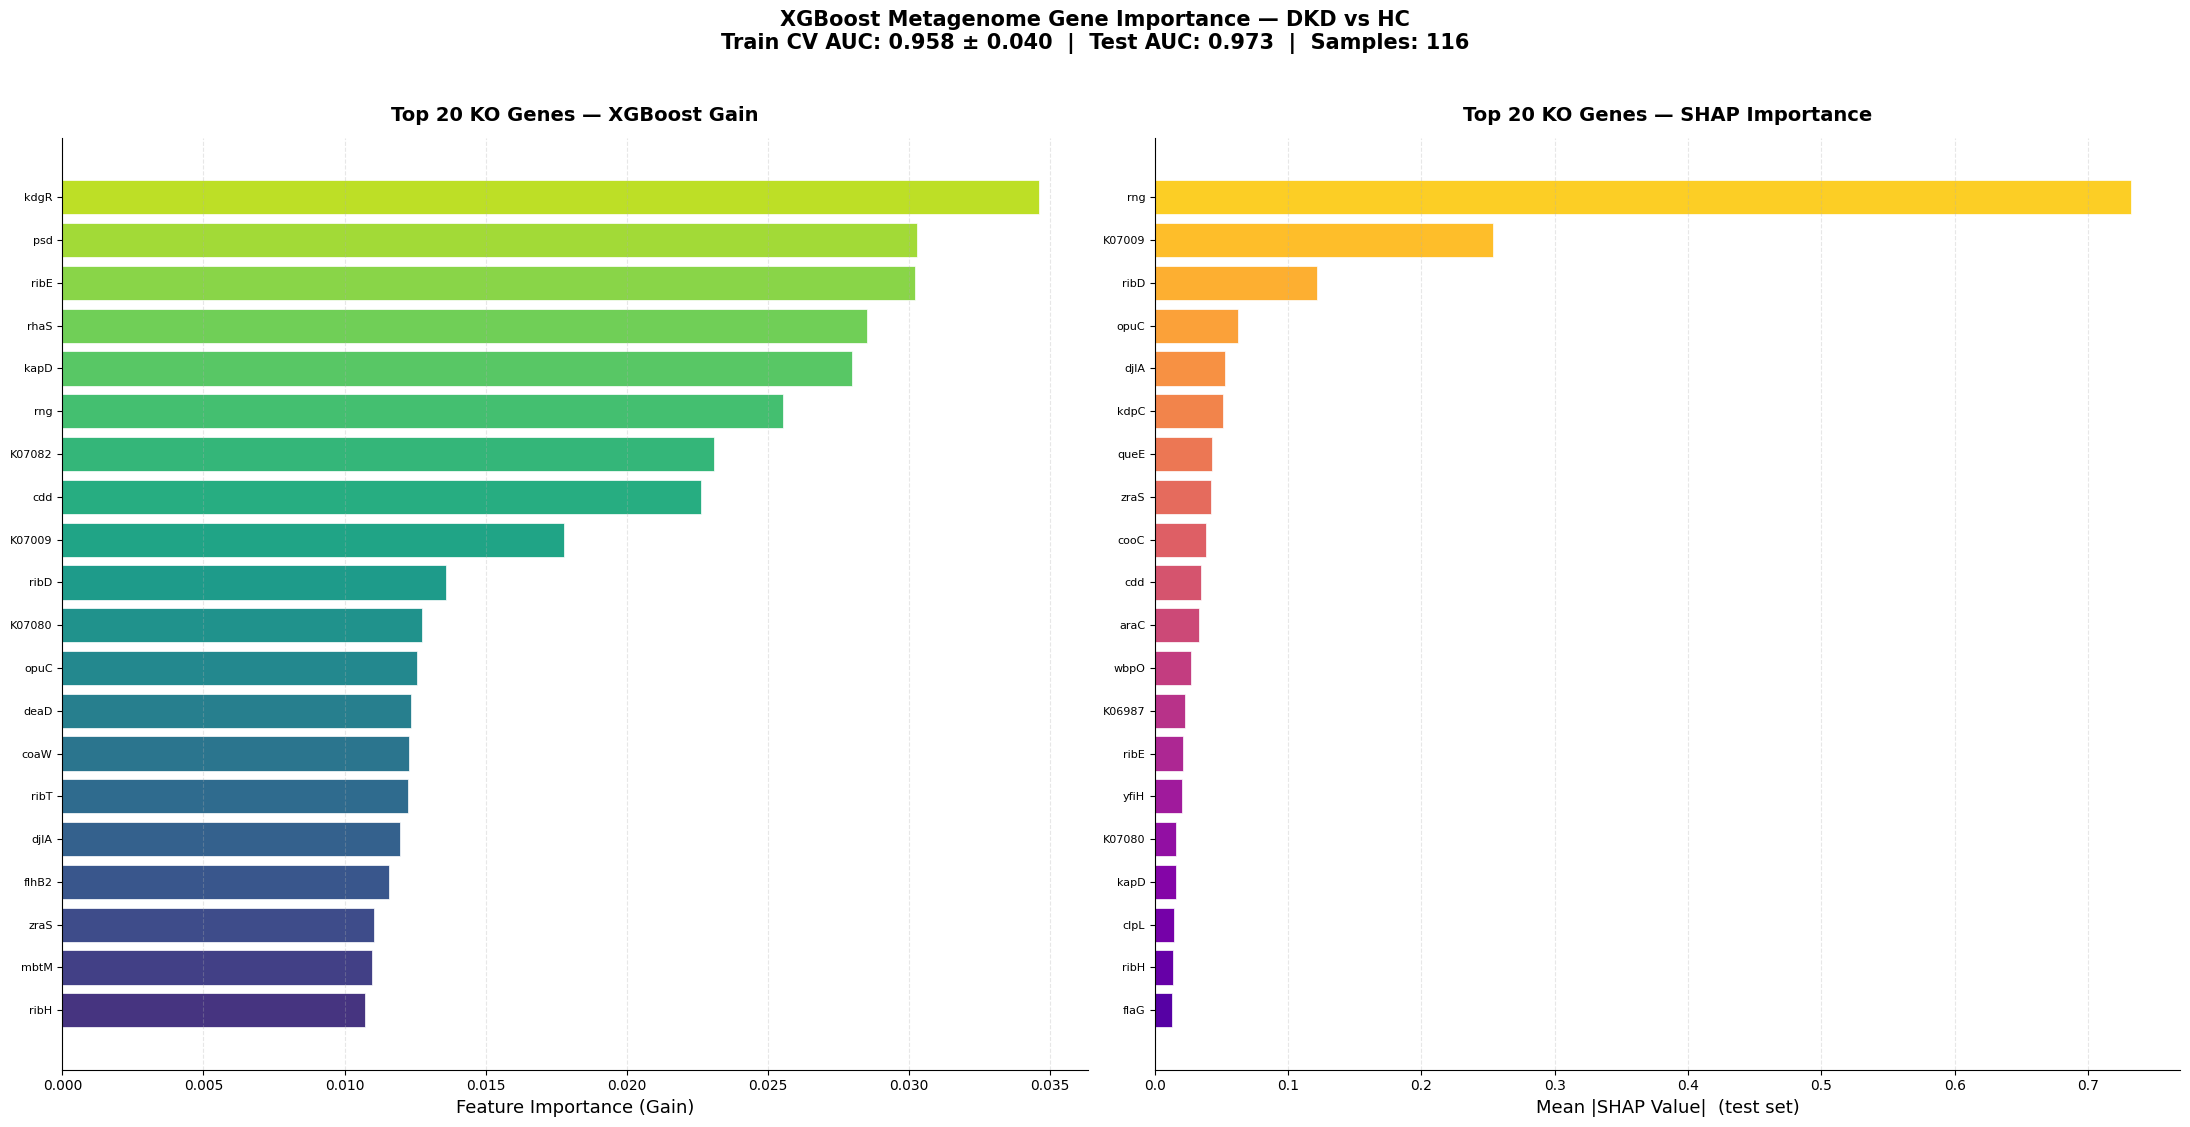

✅ Saved: importance_plots.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

top_imp = importance_df.head(TOP_N).sort_values("Importance")
cmap_a  = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_imp)))
axes[0].barh(top_imp["Label"], top_imp["Importance"],
             color=cmap_a, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Feature Importance (Gain)", fontsize=13)
axes[0].set_title(f"Top {TOP_N} KO Genes — XGBoost Gain",
                  fontsize=14, fontweight="bold", pad=12)
axes[0].tick_params(axis="y", labelsize=8)
axes[0].grid(axis="x", alpha=0.3, linestyle="--")
axes[0].spines[["top","right"]].set_visible(False)

top_shap = shap_df.head(TOP_N).sort_values("Mean_SHAP")
cmap_b   = plt.cm.plasma(np.linspace(0.15, 0.9, len(top_shap)))
axes[1].barh(top_shap["Label"], top_shap["Mean_SHAP"],
             color=cmap_b, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean |SHAP Value|  (test set)", fontsize=13)
axes[1].set_title(f"Top {TOP_N} KO Genes — SHAP Importance",
                  fontsize=14, fontweight="bold", pad=12)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].grid(axis="x", alpha=0.3, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(
    f"XGBoost Metagenome Gene Importance — DKD vs HC\n"
    f"Train CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  "
    f"Test AUC: {test_auc:.3f}  |  Samples: {len(X)}",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("importance_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: importance_plots.png")

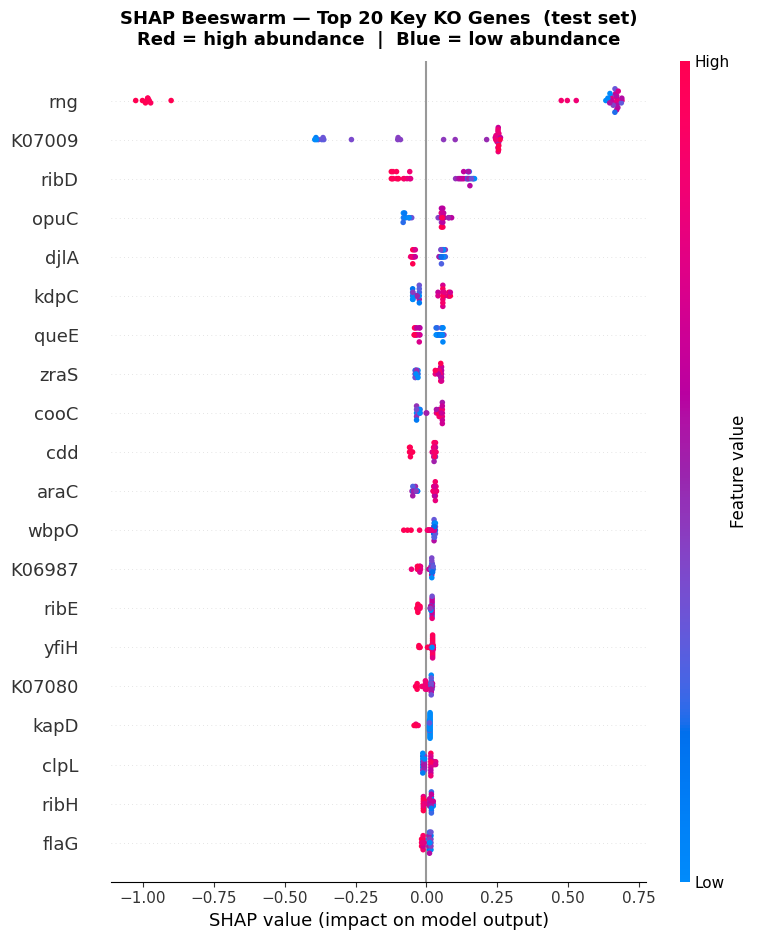

✅ Saved: shap_beeswarm.png


In [21]:
top_fids   = shap_df.head(TOP_N)["KO"].tolist()
top_idx    = [feature_names.index(f) for f in top_fids if f in feature_names]
top_labels = [shap_df.loc[shap_df["KO"] == feature_names[i], "Label"].values[0]
               for i in top_idx]

shap_vals_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
base_val       = (explainer.expected_value[0]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

explanation = shap.Explanation(
    values        = shap_vals_plot[:, top_idx],
    base_values   = base_val,
    data          = X_test[:, top_idx],
    feature_names = top_labels
)

plt.figure(figsize=(12, 11))
shap.plots.beeswarm(explanation, show=False, max_display=TOP_N)
plt.title(f"SHAP Beeswarm — Top {TOP_N} Key KO Genes  (test set)\n"
          f"Red = high abundance  |  Blue = low abundance",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.png")

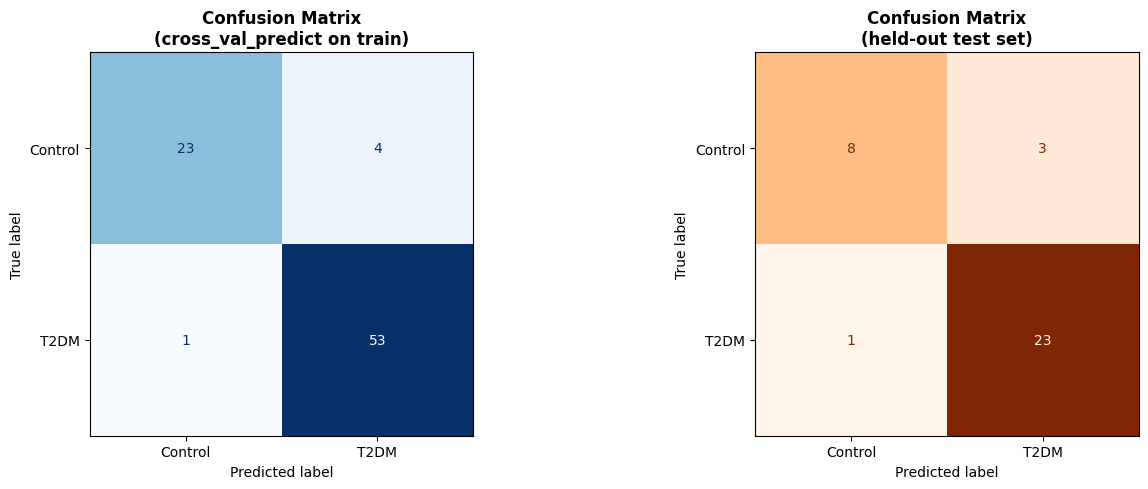


Classification Report (test set):
              precision    recall  f1-score   support

     Control       0.89      0.73      0.80        11
        T2DM       0.88      0.96      0.92        24

    accuracy                           0.89        35
   macro avg       0.89      0.84      0.86        35
weighted avg       0.89      0.89      0.88        35

✅ Saved: confusion_matrix.png


In [22]:
# ── FIX Problem 3: use cross_val_predict not training predictions ──
y_pred_cv = cross_val_predict(model, X_train, y_train,
                               cv=cv_outer, method='predict')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV predictions on train
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_cv,
    display_labels = classes,
    cmap           = "Blues",
    ax             = axes[0],
    colorbar       = False
)
axes[0].set_title("Confusion Matrix\n(cross_val_predict on train)",
                   fontsize=12, fontweight="bold")

# Held-out test set predictions
y_pred_test = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels = classes,
    cmap           = "Oranges",
    ax             = axes[1],
    colorbar       = False
)
axes[1].set_title("Confusion Matrix\n(held-out test set)",
                   fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report (test set):")
print(classification_report(y_test, y_pred_test, target_names=classes))
print("✅ Saved: confusion_matrix.png")

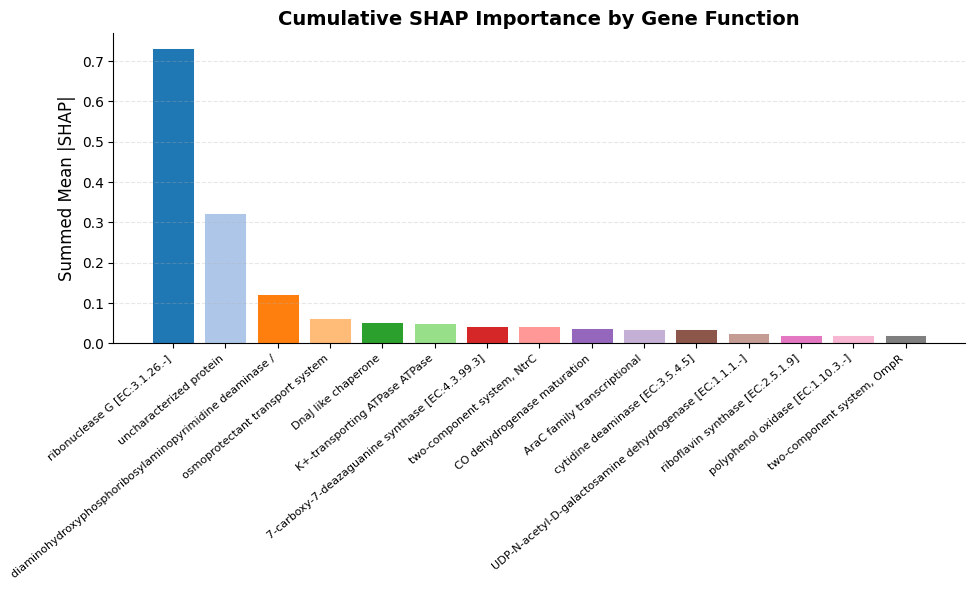

✅ Saved: gene_function_importance.png


In [23]:
shap_df["Category"] = shap_df["definition"].apply(
    lambda x: " ".join(str(x).split()[:3]) if x not in ["No annotation", "Unknown"] else "Unclassified"
)

cat_imp = (
    shap_df[shap_df["Category"] != "Unclassified"]
    .groupby("Category")["Mean_SHAP"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

if len(cat_imp) > 0:
    palette = sns.color_palette("tab20", len(cat_imp))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(cat_imp)), cat_imp["Mean_SHAP"],
           color=palette, edgecolor="white", linewidth=0.7)
    ax.set_xticks(range(len(cat_imp)))
    ax.set_xticklabels(cat_imp["Category"], rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Summed Mean |SHAP|", fontsize=12)
    ax.set_title("Cumulative SHAP Importance by Gene Function",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("gene_function_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: gene_function_importance.png")
else:
    print("⚠️  Function plot skipped — no annotations available.")

In [24]:
from google.colab import files as colab_files

importance_df.to_csv("xgboost_gene_importance.csv", index=False)
shap_df.to_csv("xgboost_shap_gene_importance.csv", index=False)
print("✅ CSVs saved")

print("\n" + "═"*55)
print("  ANALYSIS COMPLETE — SUMMARY")
print("═"*55)
print(f"  Total samples     : {len(X)}")
print(f"  Train samples     : {len(X_train)}")
print(f"  Test samples      : {len(X_test)}")
print(f"  KO genes used     : {len(feature_names)}")
print(f"  Target variable   : {TARGET_COLUMN}  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Best params       : {best_params}")
print(f"  Train CV AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Test AUC          : {test_auc:.4f}")
print(f"\n  Top 10 Key Genes (SHAP ranking — test set):")
print("  " + "─"*45)
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))
print("═"*55)

print("\n📥 Downloading result files ...")
for fname in [
    "xgboost_gene_importance.csv",
    "xgboost_shap_gene_importance.csv",
    "importance_plots.png",
    "shap_beeswarm.png",
    "confusion_matrix.png",
    "gene_function_importance.png",
]:
    try:
        colab_files.download(fname)
        print(f"   ✅ {fname}")
    except Exception as e:
        print(f"   ⚠️  {fname} — {e}")

✅ CSVs saved

═══════════════════════════════════════════════════════
  ANALYSIS COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Total samples     : 116
  Train samples     : 81
  Test samples      : 35
  KO genes used     : 5425
  Target variable   : Groups  (T2DM vs Control)
  Best params       : {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
  Train CV AUC      : 0.9576 ± 0.0402
  Test AUC          : 0.9735

  Top 10 Key Genes (SHAP ranking — test set):
  ─────────────────────────────────────────────
    KO gene_name  Mean_SHAP                                                                                                                        definition
K08301       rng   0.732297                                                                                                      ribonuclease G [EC:3.1.26.-]
K07009    K07009   0.253791                                       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ xgboost_gene_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ gene_function_importance.png
